# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tessa-Saumu/FlyRank-ML-Internship/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Tessa-Saumu/FlyRank-ML-Internship"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: c:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote C:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\data\processed\refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: C:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\data\processed\baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: C:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\data\processed\model_predictions.csv
Wrote model results: C:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\outputs\model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queu

Traceback (most recent call last):
  File "C:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\scripts\05_build_pdf_report.py", line 9, in <module>
    from reportlab.lib import colors
ModuleNotFoundError: No module named 'reportlab'
Traceback (most recent call last):
  File "c:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\scripts\run_all.py", line 48, in <module>
    main()
  File "c:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\scripts\run_all.py", line 34, in main
    run_step(index, script, label)
  File "c:\Users\ingex\OneDrive\Documents\Git Projects\FlyRank-ML-Internship\scripts\run_all.py", line 21, in run_step
    subprocess.run([sys.executable, str(ROOT / "scripts" / script)], cwd=ROOT, check=True)
  File "C:\Program Files\Python312\Lib\subprocess.py", line 571, in run
    raise CalledProcessError(retcode, process.args,
subprocess.CalledProcessError: Command '['c:\\Users\\ingex\\.venvs\\jupyter-env\\Scripts\\python.exe

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [7]:
# Set to None to display ALL columns without truncation
import pandas as pd

pd.set_option('display.max_columns', None)

In [8]:
import numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [9]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


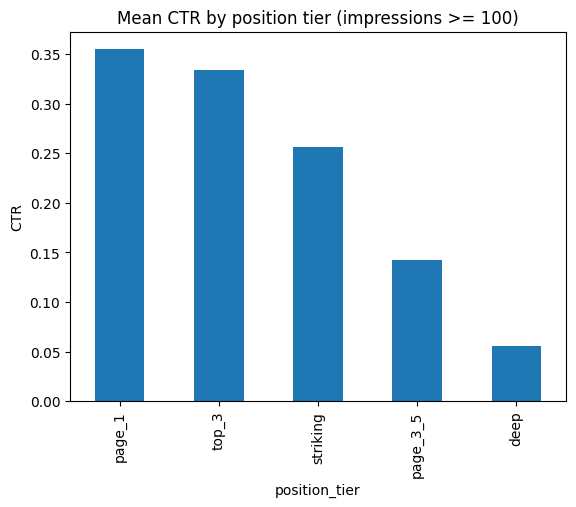

In [10]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [11]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [12]:
# Your discovery here


Redo Discovery A, impressions_90d > 0:


In [13]:
filtered_df = df[df["impressions_90d"] > 0]
corr = filtered_df["search_volume"].corr(filtered_df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("No change of correlation from the non-filtered correlation \n")

# Investigating data
print(df["impressions_90d"].describe())

print("\nMin impressions_90d is 1 so the larger than 0 filter is the entire data set\n")

for q in [0, 0.25, 0.5, 0.75]:
    # Get the threshold for the current quartile (0th, 25th, 50th, 75th)
    threshold = df["impressions_90d"].quantile(q)
    filtered_df = df[df["impressions_90d"] >= threshold]
    corr = filtered_df["search_volume"].corr(filtered_df["impressions_90d"])
    print(f"Correlation for >= {q*100:.0f}th percentile (>= {threshold}): {corr:.3f}")


print("\nCan conclusively say there si no significant correlation between these 2 variable")

Correlation between search_volume and impressions_90d: 0.001
No change of correlation from the non-filtered correlation 

count     30000.000000
mean       5200.366300
std       16838.019547
min           1.000000
25%          81.000000
50%         731.000000
75%        3615.250000
max      517715.000000
Name: impressions_90d, dtype: float64

Min impressions_90d is 1 so the larger than 0 filter is the entire data set

Correlation for >= 0th percentile (>= 1.0): 0.001
Correlation for >= 25th percentile (>= 81.0): 0.000
Correlation for >= 50th percentile (>= 731.0): -0.001
Correlation for >= 75th percentile (>= 3615.25): 0.005

Can conclusively say there si no significant correlation between these 2 variable


In Discovery B, which content_type has the worst CTR at the same position tier?

Ranking: 
 position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


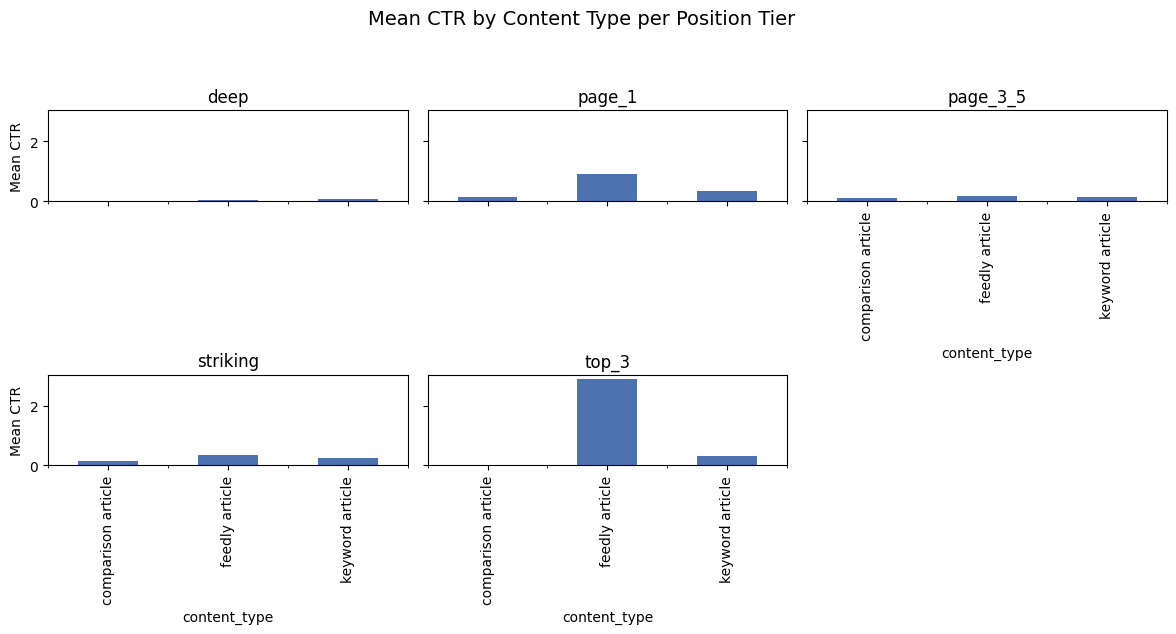


The CTR for the top 2 position tiers is driven largely by the feedly article content type


In [14]:
import matplotlib.pyplot as plt

# Filter and group (same as before)
visible = df[df["impressions_90d"] >= 100]
ctr_by_type_and_pos = visible.groupby(["content_type", "position_tier"])["ctr"].mean().unstack()

# Plot the grid with a much smaller, wider figsize
axes = ctr_by_type_and_pos.plot(
    kind="bar",
    subplots=True,
    layout=(2, 3),
    figsize=(12, 6),  # <-- Changed from (15, 10) to be much shorter
    sharey=True,
    legend=False,
    ylabel="Mean CTR",
    color="#4C72B0"
)

visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print("Ranking: \n",ctr_by_pos.round(4).to_string())

# Clean up layout
plt.suptitle("Mean CTR by Content Type per Position Tier", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("\nThe CTR for the top 2 position tiers is driven largely by the feedly article content type")

Find another belief to test: does content_age_days relate to trend_direction? Does avg_position relate to ctr?

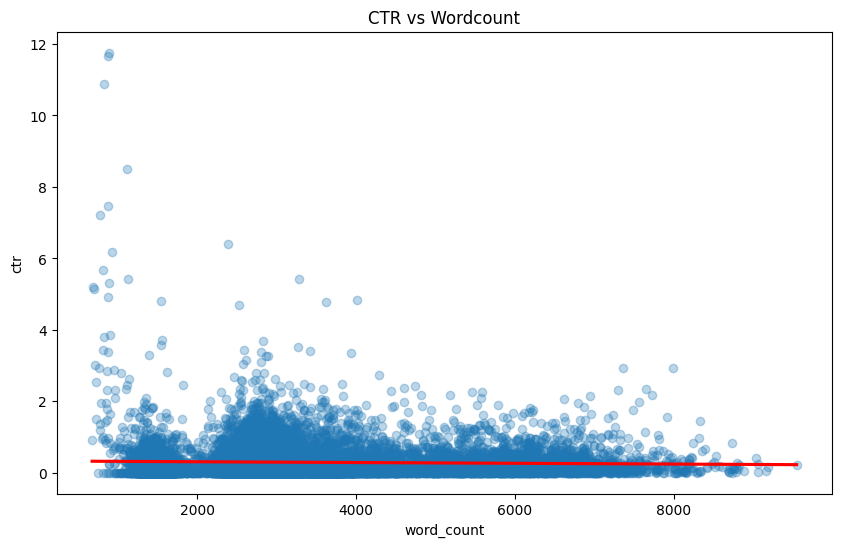

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for visible pages only
visible = df[df["impressions_90d"] >= 100]

plt.figure(figsize=(10, 6))
# regplot plots the dots and automatically calculates/draws the regression line
sns.regplot(
    data=visible,
    x="word_count",
    y="ctr",
    scatter_kws={"alpha": 0.3}, # Makes the dots slightly transparent
    line_kws={"color": "red"}   # Makes the trendline pop
)

plt.title("CTR vs Wordcount")
plt.show()

C:\Users\ingex\AppData\Local\Temp\ipykernel_28020\2190678022.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_ctr_by_tier = visible_df.groupby("wordcount_tier")["ctr"].quantile(0.95)


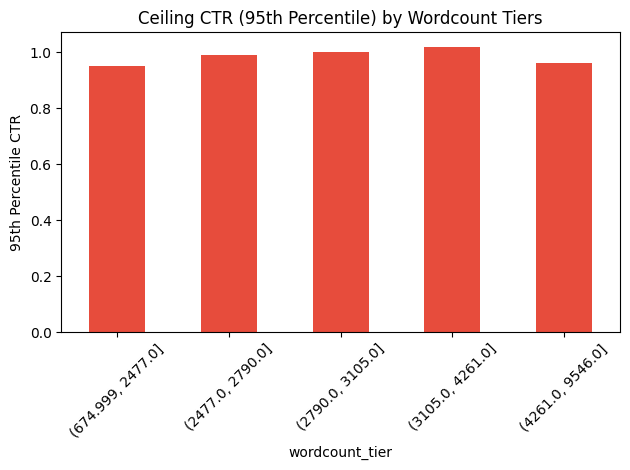

In [16]:
# Create the 5 buckets again
visible_df = df[df["impressions_90d"] >= 100].copy()
visible_df["wordcount_tier"] = pd.qcut(visible_df["word_count"], q=5, duplicates='drop')

# Calculate the 95th Percentile CTR instead of the mean
top_ctr_by_tier = visible_df.groupby("wordcount_tier")["ctr"].quantile(0.95)

# Plot it
top_ctr_by_tier.plot(
    kind="bar",
    color="#e74c3c", # Red to signify we are looking at the top edge
    title="Ceiling CTR (95th Percentile) by Wordcount Tiers",
    ylabel="95th Percentile CTR"
)
import matplotlib.pyplot as plt
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The scatter plot reveals an interesting ceiling effect for content performance. While the baseline average click-through rate remains relatively flat across all lengths, the potential for viral, outlier engagement exists almost exclusively in shorter articles. Ultimately, if you are optimizing for highly focused intent and extreme peak CTRs, the data proves that exceeding a certain word count actively eliminates your chances of achieving those highs.

C:\Users\ingex\AppData\Local\Temp\ipykernel_28020\2751921948.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ctr_grid = visible_df.groupby(["wordcount_tier", "content_type"])["ctr"].mean().unstack()


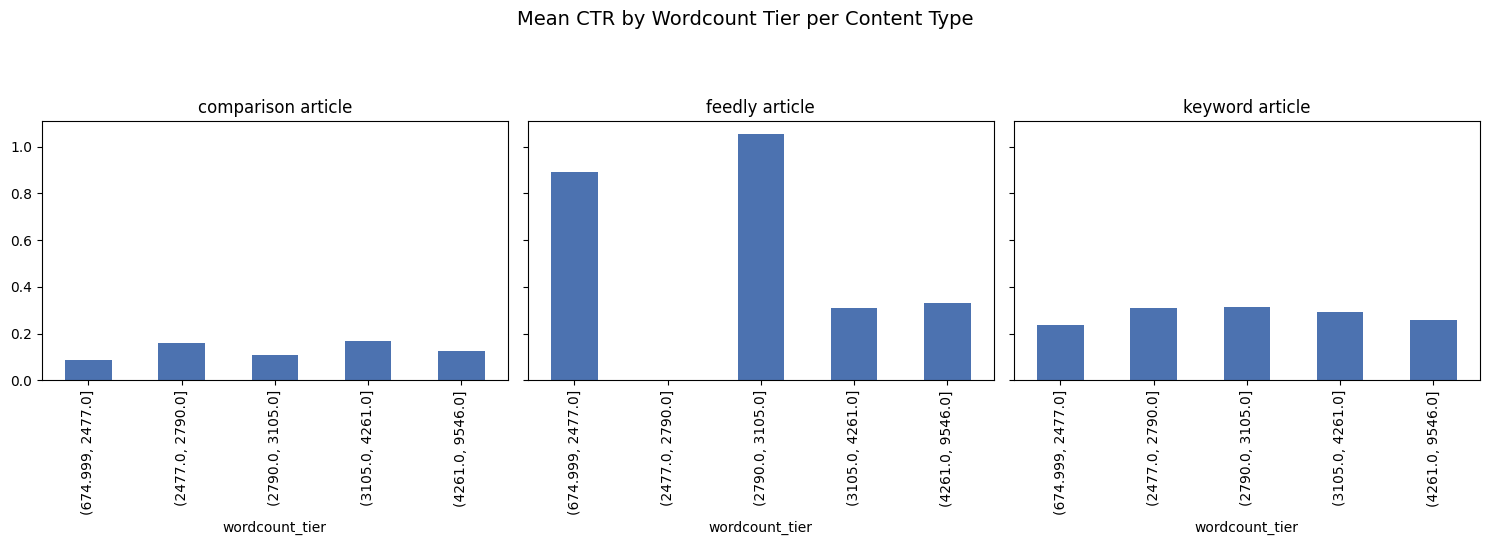


The feedly article is what was driving that high CTR for lower word counts the other content types have their lowest CTR at this tier. And the feedly peaks at a much higher word count that the other 2 content types


In [17]:
import matplotlib.pyplot as plt

# 1. Setup the dataframe and tiers
visible_df = df[df["impressions_90d"] >= 100].copy()
visible_df["wordcount_tier"] = pd.qcut(visible_df["word_count"], q=5, duplicates='drop')

# 2. Group by tier and content_type, get the MEAN ctr
mean_ctr_grid = visible_df.groupby(["wordcount_tier", "content_type"])["ctr"].mean().unstack()

# 3. Plot the grid
mean_ctr_grid.plot(
    kind="bar",
    subplots=True,
    layout=(1, 3),   # Adjust layout if you have more than 3 content types
    figsize=(15, 5),
    sharey=True,     # Keeps the Y-axis the same for accurate comparisons
    legend=False,
    color="#4C72B0"  # Back to blue for averages
)

# Clean up titles and layout
plt.suptitle("Mean CTR by Wordcount Tier per Content Type", fontsize=14, y=1.08)
plt.tight_layout()
plt.show()

print("\nThe feedly article is what was driving that high CTR for lower word counts the other content types have their lowest CTR at this tier. And the feedly peaks at a much higher word count that the other 2 content types")

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.